# Customer Segmentation — RFM Analysis & K-Means Clustering
### 01-ml-project

**Group:** `a3-g03`
This notebook builds an RFM (Recency, Frequency, Monetary) feature table from the raw transaction data, scales it, chooses a number of clusters `k` using the elbow method and silhouette score, fits K-Means, visualizes the result with PCA, and turns the clusters into named, actionable customer personas.

**Dataset:** `01-ml-project/retail_transactions_segmentation.csv` — 3,663 transactions across 300 customers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Load the Data

Loaded from the repo path, not a local machine path, so the notebook runs unchanged for anyone who pulls the repo. The first candidate path is where the file sits relative to the standard submission location (`submissions/<cohort>/<group-id>/01-ml-project/<file>.ipynb`); the others are fallbacks in case this notebook is opened with a different working directory.

In [2]:
DATA_FILENAME = "retail_transactions_segmentation.csv"

candidate_paths = [
    Path("../../../../01-ml-project") / DATA_FILENAME,  # standard submission location -> repo root
    Path("01-ml-project") / DATA_FILENAME,                # notebook run from repo root
    Path(DATA_FILENAME),                                  # notebook run from inside 01-ml-project/
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:  # last resort: walk up looking for it
    for parent in Path.cwd().parents:
        candidate = parent / "01-ml-project" / DATA_FILENAME
        if candidate.exists():
            data_path = candidate
            break

assert data_path is not None, "Could not find retail_transactions_segmentation.csv — check your working directory."
print("Loading from:", data_path.resolve())

df = pd.read_csv(data_path, parse_dates=["transaction_date"])
print(df.shape)
df.head()

Loading from: C:\Users\samaa\OneDrive\المستندات\ai_arabian\arabian-ai-training\01-ml-project\retail_transactions_segmentation.csv
(3663, 4)


,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports


In [3]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic statistics:")
display(df.describe(include="all"))

Shape: (3663, 4)

Data types:
customer_id                  int64
transaction_date    datetime64[us]
amount                     float64
product_category               str
dtype: object

Missing values:
customer_id         0
transaction_date    0
amount              0
product_category    0
dtype: int64

Duplicate rows: 0

Basic statistics:


,customer_id,transaction_date,amount,product_category
count,"3,663.00",3663,"3,663.00",3663
unique,NaN,NaN,NaN,6
top,NaN,NaN,NaN,Groceries
freq,NaN,NaN,NaN,640
mean,"5,147.31",2024-07-22 09:56:45.405405,513.03,NaN
min,"5,001.00",2024-01-01 00:00:00,5.00,NaN
25%,"5,073.00",2024-05-04 00:00:00,276.55,NaN
50%,"5,142.00",2024-07-25 00:00:00,411.87,NaN
75%,"5,223.00",2024-10-11 00:00:00,767.74,NaN
max,"5,300.00",2024-12-30 00:00:00,"1,506.36",NaN


# Data Quality Check & Cleaning


In [4]:
df_clean = df.copy()

print("Original shape:", df_clean.shape)

# 1. Missing values
print("\nMissing values:")
print(df_clean.isnull().sum())

# 2. Duplicate rows
print("\nDuplicate rows:", df_clean.duplicated().sum())

# 3. Data types
print("\nData types:")
print(df_clean.dtypes)

# 4. Check categorical values
print("\nProduct categories:")
print(df_clean["product_category"].value_counts(dropna=False))

# 5. Convert transaction date to datetime
df_clean["transaction_date"] = pd.to_datetime(df_clean["transaction_date"], errors="coerce")

# 6. Convert amount to numeric
df_clean["amount"] = pd.to_numeric(df_clean["amount"], errors="coerce")

# 7. Check invalid values
print(
    "\nInvalid transaction dates:",df_clean["transaction_date"].isna().sum())

print("Invalid amounts:", df_clean["amount"].isna().sum())

print("Invalid customer IDs:", (df_clean["customer_id"] <= 0).sum())

print("Zero/negative amounts:", (df_clean["amount"] <= 0).sum())

# 8. Remove exact duplicate rows only
df_clean = df_clean.drop_duplicates()

# 9. Remove rows missing essential RFM fields
df_clean = df_clean.dropna(subset=["customer_id", "transaction_date", "amount"])

# 10. Remove only clearly invalid transactions
df_clean = df_clean[(df_clean["customer_id"] > 0) & (df_clean["amount"] > 0)]

print("\nShape after cleaning:", df_clean.shape)

Original shape: (3663, 4)

Missing values:
customer_id         0
transaction_date    0
amount              0
product_category    0
dtype: int64

Duplicate rows: 0

Data types:
customer_id                  int64
transaction_date    datetime64[us]
amount                     float64
product_category               str
dtype: object

Product categories:
product_category
Groceries        640
Sports           630
Home & Living    611
Fashion          600
Electronics      591
Beauty           591
Name: count, dtype: int64

Invalid transaction dates: 0
Invalid amounts: 0
Invalid customer IDs: 0
Zero/negative amounts: 0

Shape after cleaning: (3663, 4)


## Point 1 — RFM Feature Table

We roll the transaction-level data (one row per purchase) up to one row per customer:

- **Recency** — days between the customer's most recent purchase and a fixed reference date. **Reference date used: `2024-12-31`** — one day after the dataset's last transaction date (`2024-12-30`), so Recency is always ≥ 1 for every customer instead of one customer sitting at exactly 0.
- **Frequency** — number of transactions for that customer.
- **Monetary** — **total spend per customer** (sum of `amount`), not the average. We picked total because it reflects overall customer value, which is what the persona/action step in Point 6 is built around.

In [5]:
REFERENCE_DATE = pd.Timestamp("2024-12-31")

rfm = (
    df_clean.groupby("customer_id")
      .agg(
          Recency=("transaction_date", lambda d: (REFERENCE_DATE - d.max()).days),
          Frequency=("transaction_date", "count"),
          Monetary=("amount", "sum"),
      )
      .reset_index()
)

print("RFM table shape:", rfm.shape)
rfm.head()

RFM table shape: (300, 4)


,customer_id,Recency,Frequency,Monetary
0,5001,2,16,"5,172.45"
1,5002,23,18,"6,158.98"
2,5003,37,3,654.12
3,5004,5,35,"31,050.88"
4,5005,26,16,"5,700.91"


## Point 2 — Scale the Features Before Clustering

Recency is in days, Frequency is a raw transaction count, and Monetary runs into the thousands of currency units — three completely different scales. K-Means clusters by Euclidean distance, so left unscaled, Monetary (by far the largest-magnitude column) would dominate that distance calculation and effectively decide the clusters on its own, drowning out Recency and Frequency. `StandardScaler` puts all three on a comparable footing (mean 0, standard deviation 1) before we cluster.

In [6]:
features = ["Recency", "Frequency", "Monetary"]
X = rfm[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).describe().round(2)

,Recency,Frequency,Monetary
count,300.00,300.00,300.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-0.79,-1.06,-0.64
25%,-0.63,-0.77,-0.58
50%,-0.35,-0.21,-0.29
75%,0.27,0.36,-0.07
max,4.14,3.09,3.44


## Point 3 — Choosing the Number of Clusters (k)

We sweep `k` from 2 to 10 and look at two diagnostics side by side: inertia (elbow method) and silhouette score.

In [7]:
k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans( n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    "k": list(k_range),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

results

,k,inertia,silhouette_score
0,2,394.21,0.68
1,3,183.03,0.68
2,4,93.39,0.57
3,5,71.41,0.52
4,6,50.34,0.52
5,7,41.13,0.46
6,8,30.22,0.48
7,9,24.12,0.48
8,10,21.07,0.48


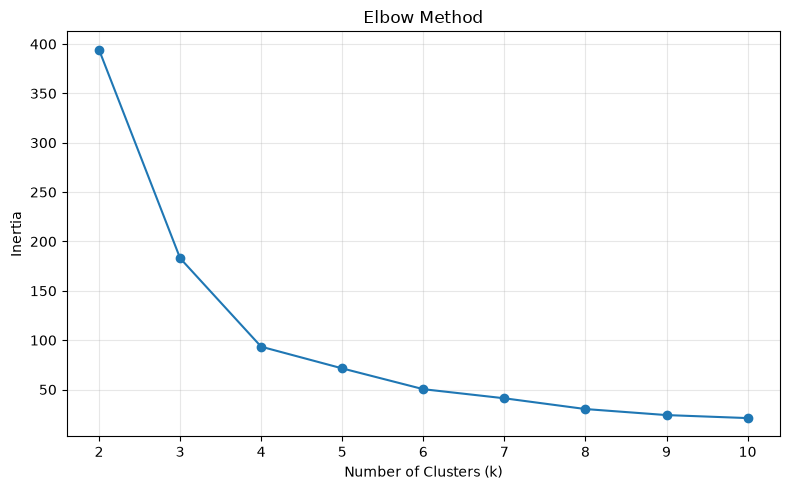

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(results["k"], results["inertia"], marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(results["k"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

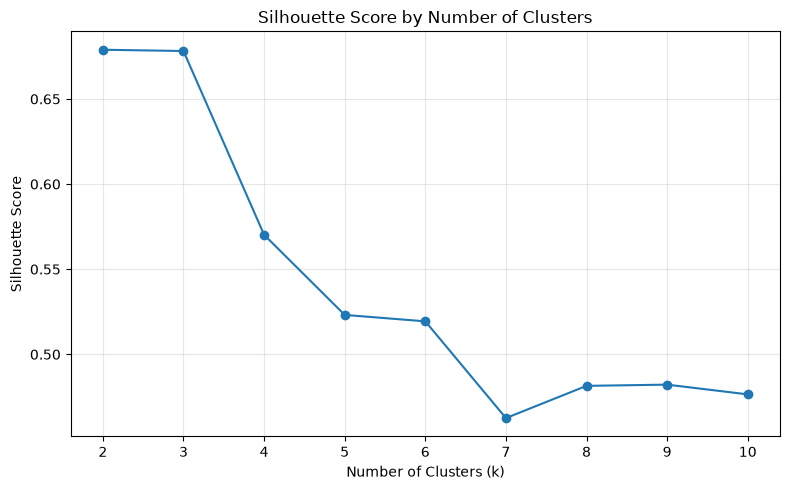

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(results["k"], results["silhouette_score"], marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.xticks(results["k"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
best_k_by_silhouette = results.loc[results["silhouette_score"].idxmax(), "k"]
best_silhouette = results["silhouette_score"].max()

print(f"Best k according to Silhouette Score: {best_k_by_silhouette}")
print(f"Best Silhouette Score: {best_silhouette:.3f}")

FINAL_K = 4

print(f"\nFinal k selected: {FINAL_K}")
print("Although the silhouette score favors a smaller number of clusters, "
      "k=4 was selected because it provides more distinct and actionable "
      "customer personas when combined with the elbow analysis and RFM profiles.")

Best k according to Silhouette Score: 2
Best Silhouette Score: 0.679

Final k selected: 4
Although the silhouette score favors a smaller number of clusters, k=4 was selected because it provides more distinct and actionable customer personas when combined with the elbow analysis and RFM profiles.


### Choosing the Final k
The silhouette score is highest at k=2 and k=3, both with a score of approximately 0.68. This indicates strong cluster separation for these values.
However, silhouette score is not the only criterion for selecting the final number of clusters. We also consider the Elbow Method and business interpretability.

The inertia values are:
- k=2 → 394.21
- k=3 → 183.03
- k=4 → 93.39
- k=5 → 71.41
- k=6 → 50.34

Inertia decreases substantially up to k=4, after which the reduction becomes smaller. Therefore, k=4 provides a practical balance between cluster compactness and segmentation detail.

Although k=2 and k=3 achieve higher silhouette scores, k=4 provides a more useful level of customer segmentation and produces distinct behavioral groups that can be translated into actionable customer personas.

**Final selected k = 4.**

## Point 4 — Fit K-Means with k = 4

In [11]:
K = FINAL_K
kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans_final.fit_predict(X_scaled)
rfm["Cluster"].value_counts().sort_index()

Cluster
0    111
1     40
2     21
3    128
Name: count, dtype: int64

## Point 5 — PCA Visualization

Reducing the three scaled RFM features to 2 principal components lets us plot the clustering result on a single readable chart.

Variance explained by PC1, PC2: [0.75  0.237] | total: 0.987


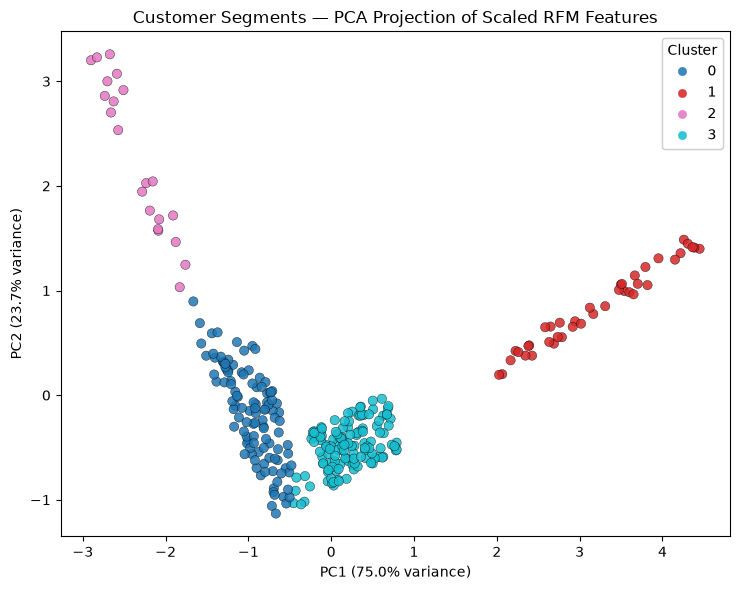

In [12]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
rfm["PC1"], rfm["PC2"] = pcs[:, 0], pcs[:, 1]

print("Variance explained by PC1, PC2:", pca.explained_variance_ratio_.round(3), "| total:", round(pca.explained_variance_ratio_.sum(), 3))

fig, ax = plt.subplots(figsize=(7.5, 6))
scatter = ax.scatter(rfm["PC1"], rfm["PC2"], c=rfm["Cluster"], cmap="tab10", s=45, alpha=0.85, edgecolor="k", linewidth=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Customer Segments — PCA Projection of Scaled RFM Features")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

## Point 6 — Personas

### Cluster RFM Averages (the evidence)

Mean Recency / Frequency / Monetary per cluster, sorted from highest to lowest spend — this table is what the persona names below are grounded in.

In [13]:
cluster_means = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
cluster_means["n_customers"] = rfm["Cluster"].value_counts()
cluster_means = cluster_means.sort_values("Monetary", ascending=False)

cluster_to_persona = {
    cluster_means.index[0]: "VIP / Champions",
    cluster_means.index[1]: "Core / Loyal Regulars",
    cluster_means.index[2]: "At-Risk / Occasional",
    cluster_means.index[3]: "Dormant / Lost"
}

cluster_means["Persona"] = cluster_means.index.map(cluster_to_persona)

rfm["Persona"] = rfm["Cluster"].map(cluster_to_persona)

cluster_means[["Persona", "Recency", "Frequency", "Monetary", "n_customers"]]

,Persona,Recency,Frequency,Monetary,n_customers
Cluster,,,,,
1,VIP / Champions,8.40,35.00,"29,683.61",40
3,Core / Loyal Regulars,20.22,13.67,"4,700.17",128
0,At-Risk / Occasional,71.57,4.23,752.49,111
2,Dormant / Lost,263.38,2.10,320.48,21


In [14]:
final_persona_table = (
    rfm.groupby("Persona")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

final_persona_table["Percentage"] = (final_persona_table["Customers"] / len(rfm) * 100).round(2)

final_persona_table = final_persona_table.sort_values("Avg_Monetary", ascending=False)

display(final_persona_table)

print("Total customers:", final_persona_table["Customers"].sum())
print("Total percentage:", final_persona_table["Percentage"].sum())

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Percentage
Persona,,,,,
VIP / Champions,40,8.40,35.00,"29,683.61",13.33
Core / Loyal Regulars,128,20.22,13.67,"4,700.17",42.67
At-Risk / Occasional,111,71.57,4.23,752.49,37.00
Dormant / Lost,21,263.38,2.10,320.48,7.00


Total customers: 300
Total percentage: 100.0


### Persona Summary

**VIP / Champions — 40 customers (13.33%)**
Recency = 8.40 days, Frequency = 35.00 purchases, and Monetary = 29,683.61. This segment has the lowest Recency, highest Frequency, and highest Monetary value. These are the most valuable and engaged customers.

**Recommended actions:**
Protect this segment with loyalty rewards, early access to new products, personalized offers, and priority customer service.

**Core / Loyal Regulars — 128 customers (42.67%)**
Recency = 20.22 days, Frequency = 13.67 purchases, and Monetary = 4,700.17. This is the largest segment and represents customers who purchase regularly and generate consistent revenue.

**Recommended actions:**
Encourage repeat purchases through loyalty points, cross-selling, product bundles, and personalized recommendations. High-potential customers can be nurtured toward the VIP segment.

**At-Risk / Occasional — 111 customers (37.00%)**
Recency = 71.57 days, Frequency = 4.23 purchases, and Monetary = 752.49. These customers have not purchased recently and show lower engagement compared with the Core and VIP segments.

**Recommended actions:**
Use targeted win-back campaigns, personalized recommendations, and limited-time incentives to encourage another purchase.

**Dormant / Lost — 21 customers (7.00%)**
Recency = 263.38 days, Frequency = 2.10 purchases, and Monetary = 320.48. These customers have been inactive for most of the year and have relatively low historical engagement and spending.

**Recommended actions:**
Use low-cost automated reactivation campaigns, such as win-back emails or general reactivation offers, rather than expensive high-touch campaigns.